# Aprendizado por Reforço - Reinforcement learning
O agente de software que faz as observações e realiza ações em um ambiente, aprende por tentativa e erro a maximizar sua satisfação e minimizar sua dor.

## Pesquisa de políticas
O algoritimo que um agente usa para determinar suas ações se chama política. A política pode ser uma rede neural tomando observações como entradas e gerando como saída a ação a ser executada.

As vezes não precisamos observar o ambiente, e seguir de forma aleatória. Isso se chama _política estocástica_. Para treinar dessa forma, podemos testar diversas combinações para encontrar a que tem melhor desempenho, um exemplo de _pesquisa de política_. Quando o _espaço da política_ é muito grande (o que geralmente é o caso), encontrar um bom conjunto de parâmetros é como procurar uma agulha no palheiro.

Outra forma de explorar o espaço da política é usar _algoritmos genéticos_. Por exemplo, você pode criar aleatoriamente uma primeira geração de 100 políticas e testá-las, depois, "eliminar" as 80 piores e fazer com que as 20 restantes criem 4 descendentes cada. Uma descendente é uma cópia de seu pai, além de herdar um pouco de variação aleatória. Você pode continuar a iterar por meio das gerações dessa maneira até encontrar uma boa política.

Outra abordagem é usar técnicas de otimização, avaliando os gradientes das recompensas em relação aos parâmetros da política e, em seguida, ajustar esses parâmetros seguindo os gradientes em direção a recompensas mais altas.

## Introdução ao OpenAI Gym (onde criamos os agentes de software)
* Obs: caso queiramos utilizar um ambiente 3D, podemos utilizar PyBullet ou MuJoCo para simulação física 3D.
* Obs 2: OpenAI Gym agora se chama Gymnasium, o que muda algumas coisas no código: https://gymnasium.farama.org/introduction/migration_guide/

O OpenAI Gym é um conjunto de ferramentas que viabiliza uma ampla variedade de ambientes simulados para que possamos treinar nossos agentes, compará-los ou desenvolver novos algoritmos de RL.

In [5]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset()
obs, info

(array([-0.02132147, -0.04504258,  0.03817615, -0.0093693 ], dtype=float32),
 {})

Aqui criamos um ambiente CartPole, uma simulação 2D na qual podemos acelerar um carrinho para esqueda ou direita a fim de equilibrar uma haste em cima dele.

* você pode obter a lista de todos os ambientes usando `gym.envs.registry.all()`

Depois que o ambiente é criado, você deve inicializá-lo usando o método `reset()`. Isso retorna a primeira observação.
Vamos exibir este ambiente usando o método `render()`, onde precisamos especificar o render mode. Coloquei o render mode no .make() do ambiente.

In [7]:
import matplotlib.pyplot as plt 
img = env.render()

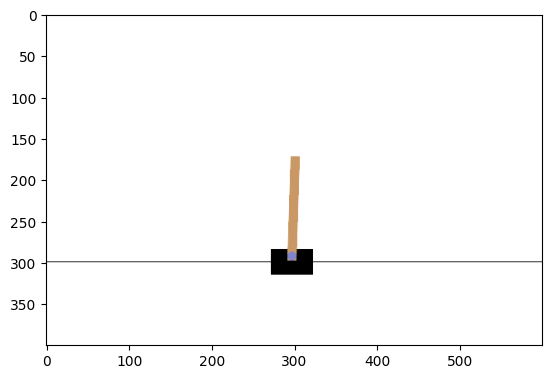

In [8]:
plt.imshow(img)

In [9]:
# agora, perguntaremos ao ambiente quais ações são possíveis:
env.action_space

Discrete(2)

In [10]:
# Discrete(2) significa que as ações possíveis são inteiros 0 e 1, que representam a aceleração para esquerda (0) ou para direita (1). Vamos acelerar o carrinho para direita
action = 1
obs, reward, terminated, truncated, info = env.step(action=action)
obs

array([-0.02222233,  0.14951167,  0.03798876, -0.28976697], dtype=float32)

In [11]:
reward

1.0

In [12]:
terminated

False

In [13]:
truncated

False

In [14]:
info

{}

O método `step()` executa a ação fornecida e retorna cinco valores:

## Obs
    Esta é a nova observação. Agora o carrinho está se movimentando para a direita.

## Reward
    Neste ambiente, você recebe uma recompensa de 1.0 em cada intervalo, seja lá o que seja feito. Portanto o objetivo é manter o episódio rodando o maior tempo possível

## Truncated
    Para previnir do agente ficar em ciclos para sempre, não fazer nada e por outras razões práticas, Gym deixa os ambientes terem a opção de especificar um tempo limite que o agente precisa completar o ambiente. Quando o agente chega nesse tempo limite, o ambiente deve resetar, mas não deve ser tratado como o mesmo do que se o agente alcançasse um objetivo e o ambiente acabasse. Nos referimos ao primeiro tipo como "truncation", quando o agente atinge o limite (máximo número de steps) para o ambiente

## Terminated 
    Quando o ambiente chega em uma condição específica.

## Info
    Este dicionário específico do ambiente tem a possibilidade de fornecer algumas informações extras que podem ajudar no debugging de treinamento.


* Após terminar de usar um ambiente, você deve chamar o método `close()`para liberar recursos



Vamos embutir no código uma política simples que acelerar a haste para a esquerda quando ela está inclinada à esquerda e a acelera para direita, quando está inclinada para direita. Executaremos essa política para ver as recompensas médias recebidas em 500 episódios.

In [15]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []

for episode in range(500):
    episode_rewards = 0
    obs, info = env.reset()

    for step in range(200):
        action = basic_policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_rewards += reward
        if terminated or truncated:
            break
    totals.append(episode_rewards)

In [16]:
import numpy as np
np.mean(totals), np.std(totals), np.min(totals), np.max(totals)

(np.float64(41.632),
 np.float64(8.674593708064949),
 np.float64(24.0),
 np.float64(68.0))

Mesmo com 500 tentativas, essa política nunca conseguiu manter a haste em pé por mais de 68 intervalos consecutivos. Vejamos se uma rede neural pode sugerir uma política melhor

# Políticas de Rede Neural
Assim como a política que embutimos no código anterior, essa rede neural pegará uma observação como entrada e gerará como saída a ação a ser executada. Ela estimará a probabilidade para cada ação e, em seguida, selecionaremos uma ação aleatoriamente, de acordo com as probabilidades estimadas. Para o CartPole existem apenas duas ações a serem tomadas, logo, precisaremos de apenas um neurônio de saída. Ele gerará a probabilidade $p$ da ação 0 (esquerda) e a probabilidade da ação 1 (direita) será $1 - p$. Exemplo: Caso a saída seja 0.7, escolheremos a ação com 70% de probabilidade ou a ação 1 com 30% de probabilidade.

In [17]:
import keras

n_inputs = 4 # == env.observation_space.shape[0]

model = keras.models.Sequential([
    keras.layers.Input(shape=[n_inputs]),
    keras.layers.Dense(5, activation="elu"),
    keras.layers.Dense(1, activation="sigmoid")
])